# Faithful replication of De Stefano et al. (2025) — firm–product network layer
### Chinese customs data · late-8 sample (2008–2015) · HS6

**De Stefano, Mula, Mariani, Zaccaria (2025), *From macro to micro: economic complexity indicators for firm
growth*** (arXiv:2507.21754 → *Research Policy*). This notebook follows **their pipeline, in their order, with
their formulas**, on Chinese firm-level exports. Self-contained: only input is the raw `.dta`.

**Their pipeline (what we follow step by step):**
1. Keep firms exporting **every year** (balanced panel); binarise the **pooled** firm×product matrix with Balassa **RCA**.
2. **BRIM** (Barber 2007) bipartite community detection → frozen capability **blocks**.
3. **In-block / out-of-block diversification** \(d^{in}, d^{out}\) from \(\delta_{fp}=\mathbb 1\{\text{block}(f)=\text{block}(p)\}\).
4. **Coherence** via **Sapling Similarity** (Albora 2023).
5. **Fitness–Complexity** (Tacchella 2012) — their Appendix C check.
6. Validate the partition by comparing **BRIM blocks vs naïve HS-sector blocks** (their Table 2 logic).

**Scope / honesty — what we can and cannot replicate on these data.** We have Chinese firm × product ×
destination exports only. Two ingredients of their paper need data we do **not** have, so we document the
formulas but do **not** compute them (see §10):
- **EXPY / PRODY** — needs the *world* country-product trade matrix + GDP per capita (the country-product
  network), not a single country's firm exports.
- **Their regressions on Growth and Profit/Employee** — need ORBIS firm financials.

Everything else (steps 1–6) is computed exactly as they describe. Graphics are deliberately plain
(grayscale, serif) in the style of an econometrics paper.

## 0b. Fidelity audit — did we do *exactly* what De Stefano do?
Their exact recipe (quoted from the paper, §4 + Appendix B):
- *"M_fp = 1 if **RCA_fp > 1**"* — strict Balassa threshold.
- *"firms that exported **at least one product per year throughout the entire period**, from **1993 to 2017**"* — balanced panel.
- *"constructed a **single aggregate firm-product graph, averaging connections throughout all years** … calculated
  the RCA for the resulting export matrix and eliminated all firm-product links with RCA < 1"* — one frozen, aggregated matrix.
- BRIM (Barber 2007), modularity \(Q\) (Newman, Eq. B.1); they obtain \(Q=0.501\), 7 blocks.
- Coherence \(C_f=\sum_{p,p'}E_{fp}E_{fp'}B_{pp'}/\sum_{p,p'}E_{fp}E_{fp'}\) with Sapling-Similarity \(B\) (Albora 2023).

| Step | De Stefano | This notebook | Identical? |
|---|---|---|---|
| Firm–product RCA | Balassa (their Eq. 1) | same Balassa formula | **yes** |
| Threshold | \(\mathrm{RCA}>1\) (strict) | \(\mathrm{RCA}>1\) (strict) | **yes** (fixed) |
| Aggregation | average connections over all years → 1 matrix | **sum** export value over years → 1 matrix | **equivalent** under a balanced panel (mean = sum/T, a global constant ⇒ identical RCA & identical binary M) |
| Sample rule | ≥1 product every year | ≥1 product every year | **yes (rule)** |
| Sample window | **1993–2017** (25 yrs) | **2008–2015** (late-8, 8 yrs) | **no — deliberate sub-period** (we don't have 1993–2017; this is a late-window cut of Chinese data) |
| Community detection | BRIM only | BRIM (canonical) **+ Louvain/Leiden shown** | superset (extra is flagged, not used downstream) |
| Coherence | all products | **top-1500 products** (compute cap; \(B\) is \(P\times P\) dense) | approximation |
| d_in/d_out, δ_fp | as defined | identical | **yes** |
| EXPY/PRODY, growth regressions | computed | **documented, not computed** (need world country-product+GDP / ORBIS) | not replicated (data) |

**Bottom line.** The *core network pipeline* (RCA → aggregate matrix → strict RCA>1 → BRIM → δ_fp → d_in/d_out →
coherence with their exact formula → Fitness) is reproduced faithfully. The only **intended** departure is the
**time window** (late-8 vs their 25-year span); two minor approximations (sum-vs-mean aggregation — equivalent
here; coherence on the 1500 busiest products) and one **addition** (Louvain/Leiden, shown for transparency, BRIM
kept canonical). EXPY and the growth/profit regressions are out of reach on these data and are documented, not faked.

## 1. Configuration

In [1]:
from pathlib import Path
RAW_DTA = Path.home() / "Desktop" / "my-project" / "data" / "raw" / "export_2000_2015.dta"

COL_FIRM, COL_YEAR, COL_HS6, COL_VALUE = "companyID", "year", "hs6", "export"
USECOLS  = [COL_FIRM, COL_YEAR, COL_HS6, COL_VALUE]
CHUNKSIZE = 2_000_000

YEARS         = list(range(2008, 2016))   # late-8 window (2008-2015)
LEVEL         = "hs6"
RCA_THRESHOLD = 1.0                        # Balassa cutoff: M_fp = 1{RCA_fp > 1} (STRICT, exactly as De Stefano)
RESOLUTION    = 1.0                        # Leiden RB-configuration resolution
ALGORITHMS    = ["louvain", "leiden", "brim"]
COH_MAX_PRODUCTS = 1500                    # cap products for the Sapling B matrix (P x P dense)
SEED          = 0

# De Stefano (2025) Italian benchmark (Appendix B) for reference
DESTEFANO = {"blocks": 7, "Q_B": 0.501, "firms": 18597, "hs6": 5203}
assert RAW_DTA.exists(), f"set RAW_DTA -- not found: {RAW_DTA}"
print(f"sample: {YEARS[0]}-{YEARS[-1]} (late-8) | level: {LEVEL} | balanced (exports every year)")

sample: 2008-2015 (late-8) | level: hs6 | balanced (exports every year)


## 2. Imports, reproducibility & plain (paper-style) plotting
One `SEED` drives the Leiden/BRIM optimiser and any random step. Plots are grayscale + serif, no decorative
colour maps, in the style of De Stefano's figures.

In [2]:
import time, platform
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from IPython.display import display

rng = np.random.default_rng(SEED)
OUT = RAW_DTA.parents[2] / "notebooks" / "_outputs"; OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "dejavuserif",
    "axes.grid": False, "axes.edgecolor": "black", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 11, "legend.frameon": False,
})
BLACK, GRAY, LGRAY = "black", "0.45", "0.80"

def save_fig(fig, name):
    fig.savefig(OUT / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUT / f"{name}.png", dpi=300, bbox_inches="tight")

def show(df, caption=None):
    if caption: print(caption)
    display(df.round(3))

def summary_stats(frame, cols):
    """Classic descriptive table: N, mean, sd, min, p10, p25, median, p75, p90, max."""
    out = {}
    for c in cols:
        s = pd.to_numeric(frame[c])
        out[c] = {"N": int(s.notna().sum()), "mean": s.mean(), "sd": s.std(), "min": s.min(),
                  "p10": s.quantile(.10), "p25": s.quantile(.25), "median": s.median(),
                  "p75": s.quantile(.75), "p90": s.quantile(.90), "max": s.max()}
    return pd.DataFrame(out).T

def binned_mean(x, y, bins=20):
    x = np.asarray(x, float); y = np.asarray(y, float)
    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    b = np.clip(np.digitize(x, edges[1:-1]), 0, bins - 1)
    mx = np.array([x[b == k].mean() if (b == k).any() else np.nan for k in range(bins)])
    my = np.array([y[b == k].mean() if (b == k).any() else np.nan for k in range(bins)])
    return mx, my
print("python", platform.python_version(), "| igraph", ig.__version__)

python 3.14.3 | igraph 1.0.0


## 3. Ingest the raw microdata → firm × product × year (HS6, late-8 years)
Chunked `pandas.read_stata`; firm string IDs factorised to a stable integer code; collapse to
firm × HS6 × year export value. Only the eight late years are kept.

In [3]:
t0 = time.time()
yrs = set(YEARS); firm_codes = {}; parts = []
reader = pd.read_stata(RAW_DTA, columns=USECOLS, chunksize=CHUNKSIZE, convert_categoricals=False)
for i, chunk in enumerate(reader):
    chunk = chunk[pd.to_numeric(chunk[COL_YEAR]).isin(yrs)]
    if not len(chunk):
        continue
    fid = chunk[COL_FIRM].astype(str); codes = fid.map(firm_codes)
    new = fid[codes.isna()].unique()
    if len(new):
        base = len(firm_codes); firm_codes.update({f: base + j for j, f in enumerate(new)}); codes = fid.map(firm_codes)
    d = pd.DataFrame({"firm": codes.to_numpy(np.int32),
                      "prod": pd.to_numeric(chunk[COL_HS6]).to_numpy(np.int32),
                      "year": pd.to_numeric(chunk[COL_YEAR]).to_numpy(np.int16),
                      "value": pd.to_numeric(chunk[COL_VALUE]).to_numpy(np.float64)})
    d = d[d.value > 0]
    parts.append(d.groupby(["firm", "prod", "year"], sort=False)["value"].sum().reset_index())
panel = pd.concat(parts, ignore_index=True).groupby(["firm", "prod", "year"], sort=False)["value"].sum().reset_index()
del parts
N_FIRMS = int(panel.firm.max()) + 1
PROD = np.sort(panel["prod"].unique()); PCOL = {h: i for i, h in enumerate(PROD)}
panel["col"] = panel["prod"].map(PCOL).to_numpy(np.int32)
print(f"panel rows {len(panel):,} | firms {N_FIRMS:,} | HS6 {len(PROD):,} | "
      f"years {panel.year.min()}-{panel.year.max()} | {time.time()-t0:.0f}s")

panel rows 11,923,680 | firms 372,030 | HS6 4,657 | years 2008-2015 | 15s


### HS chapter → section lookup (Harmonized System, WCO)
Used to label blocks and for the BRIM-vs-HS-sector comparison in §6.

In [4]:
_HS = [(1,5,'Animals'),(6,14,'Vegetables'),(15,15,'Fats&oils'),(16,24,'Foodstuffs'),(25,27,'Minerals'),
       (28,38,'Chemicals'),(39,40,'Plastics&rubber'),(41,43,'Hides&skins'),(44,46,'Wood'),(47,49,'Paper'),
       (50,63,'Textiles'),(64,67,'Footwear'),(68,70,'Stone&glass'),(71,71,'Precious'),(72,83,'Base metals'),
       (84,85,'Machinery&electrical'),(86,89,'Transport'),(90,92,'Instruments'),(93,93,'Arms'),
       (94,96,'Misc manuf'),(97,97,'Art')]
def section_name(hs6):
    ch = int(hs6) // 10000
    for lo, hi, nm in _HS:
        if lo <= ch <= hi:
            return nm
    return '?'
SECNAME = np.array([section_name(h) for h in PROD])

## 4. Sample restriction — balanced panel (exactly as De Stefano)
> *De Stefano keep only firms that export at least one product in **every** year of the sample, to obtain a
> balanced panel suitable for longitudinal analysis (their §2 / Appendix B).*

We apply the identical rule to the late-8 window: a firm is kept iff it appears (exports >0) in **all eight
years** 2008–2015. The descriptive read-out below mirrors their data section, point by point.

In [5]:
ypf = panel.groupby("firm")["year"].nunique()
KEEP = np.sort(ypf.index[ypf.eq(len(YEARS))].to_numpy())
panel_k = panel[panel.firm.isin(set(KEEP))]

rows = {
    "firms, all (any year in window)":      panel.firm.nunique(),
    "firms, balanced (every year)":         len(KEEP),
    "  -> share kept":                      len(KEEP) / panel.firm.nunique(),
    "HS6 products (balanced sample)":       panel_k["prod"].nunique(),
    "export value share kept":              panel_k.value.sum() / panel.value.sum(),
    "mean HS6 lines per firm-year (balanced)": panel_k.groupby(["firm","year"]).size().mean(),
}
desc = pd.DataFrame({"value": rows}).round(4)
show(desc, "De Stefano-style data summary (late-8, HS6)")

De Stefano-style data summary (late-8, HS6)


,value
"firms, all (any year in window)",372030.000
"firms, balanced (every year)",71017.000
-> share kept,0.191
HS6 products (balanced sample),4586.000
export value share kept,0.621
mean HS6 lines per firm-year (balanced),9.538


## 5. Step 1 — Balassa RCA and binarisation
> *De Stefano binarise a pooled (time-averaged) firm–product matrix with the Balassa revealed comparative
> advantage index.* For firm \(f\), product \(p\), with \(X_{fp}\) the pooled export value over the window,
$$\mathrm{RCA}_{fp}=\frac{X_{fp}\big/\sum_{p'}X_{fp'}}{\sum_{f'}X_{f'p}\big/\sum_{f'p'}X_{f'p'}},\qquad
M_{fp}=\mathbb 1\{\mathrm{RCA}_{fp}> 1\}.$$
(De Stefano use the **strict** inequality \(\mathrm{RCA}_{fp}>1\); we follow it exactly.)
The binary matrix \(M\) is the bipartite firm–product network. Two basic descriptors (point by point):
**diversification** \(d_f=\sum_p M_{fp}\) (how many products a firm makes competitively) and **ubiquity**
\(u_p=\sum_f M_{fp}\) (how many firms make a product).

M: 372,030 firms x 4,657 products | active firms 71,017 | used products 4,586 | links 1,103,737
diversification d_f: mean 15.5, median 8, max 1005 | single-product firms 4,294 (6%)
ubiquity u_p: mean 241, median 101, max 7474


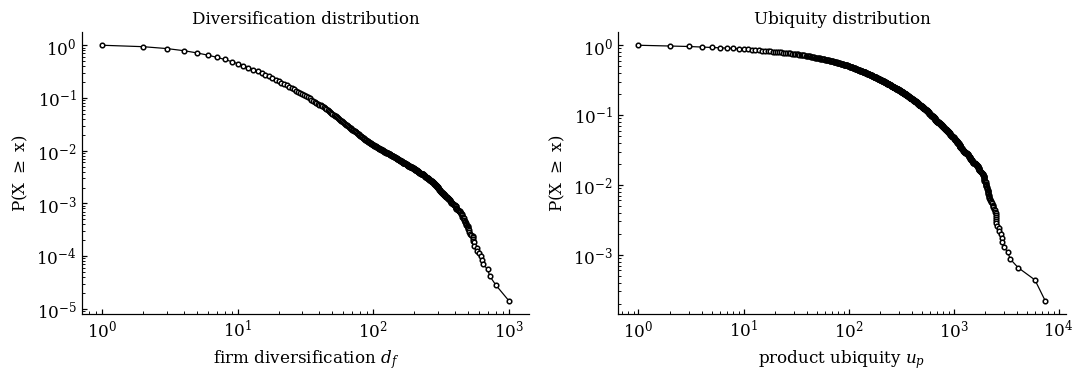

In [6]:
def build_pooled_M(panel_sub, firms):
    sub = panel_sub[panel_sub.firm.isin(set(firms))]
    pooled = sub.groupby(["firm", "col"], sort=False)["value"].sum().reset_index()
    F, P = N_FIRMS, len(PROD)
    X = sp.csr_matrix((pooled.value.to_numpy(np.float64),
                       (pooled.firm.to_numpy(np.int64), pooled.col.to_numpy(np.int64))), shape=(F, P))
    rs = np.asarray(X.sum(1)).ravel(); cs = np.asarray(X.sum(0)).ravel(); tot = X.data.sum()
    coo = X.tocoo(); den = rs[coo.row] * cs[coo.col]
    rca = np.where(den > 0, coo.data * tot / den, 0.0); k = rca > RCA_THRESHOLD   # strict ">", as De Stefano
    return sp.csr_matrix((np.ones(int(k.sum()), np.int8), (coo.row[k], coo.col[k])), shape=(F, P))

M = build_pooled_M(panel_k, KEEP)
div = np.asarray(M.sum(1)).ravel(); ubi = np.asarray(M.sum(0)).ravel()
div_a = div[div > 0]; ubi_a = ubi[ubi > 0]
print(f"M: {M.shape[0]:,} firms x {M.shape[1]:,} products | active firms {len(div_a):,} | "
      f"used products {len(ubi_a):,} | links {M.nnz:,}")
print(f"diversification d_f: mean {div_a.mean():.1f}, median {np.median(div_a):.0f}, max {div_a.max()} | "
      f"single-product firms {(div_a==1).sum():,} ({100*(div_a==1).mean():.0f}%)")
print(f"ubiquity u_p: mean {ubi_a.mean():.0f}, median {np.median(ubi_a):.0f}, max {ubi_a.max()}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a, dat, lab in [(ax[0], div_a, "firm diversification $d_f$"), (ax[1], ubi_a, "product ubiquity $u_p$")]:
    v, c = np.unique(dat, return_counts=True); ccdf = c[::-1].cumsum()[::-1] / c.sum()
    a.loglog(v, ccdf, marker="o", ms=3, color=BLACK, lw=0.8, mfc="white")
    a.set_xlabel(lab); a.set_ylabel("P(X $\\geq$ x)")
ax[0].set_title("Diversification distribution", fontsize=11)
ax[1].set_title("Ubiquity distribution", fontsize=11)
plt.tight_layout(); save_fig(fig, "ds_fig1_distributions"); plt.show()

## 6. Step 2 — Community detection
> *De Stefano detect capability blocks with **BRIM** (Barber 2007), the bipartite-aware modularity, on the
> pooled binary matrix, and they validate the choice by showing the data-driven blocks matter more than naïve
> HS-sector blocks (their Table 2).*

**Standard modularity (Newman 2006)** on a graph with adjacency \(A\), degrees \(k\), \(m\) edges:
$$Q=\frac1{2m}\sum_{ij}\Big(A_{ij}-\frac{k_ik_j}{2m}\Big)\delta(c_i,c_j).$$
**Bipartite (Barber 2007)** modularity for a firm×product incidence \(B\) with firm degrees \(k\), product
degrees \(d\), \(m=\sum_{fp}B_{fp}\):
$$Q_B=\frac1m\sum_{fp}\Big(B_{fp}-\frac{k_f\,d_p}{m}\Big)\delta(g_f,g_p).$$
Louvain and Leiden optimise the *standard* \(Q\) on the bipartite graph; **BRIM** optimises \(Q_B\) (the correct
bipartite null) — this is De Stefano's choice. We report all three for transparency, then carry BRIM forward.

In [7]:
def bipartite_brim(Mat, gamma=RESOLUTION, seed=SEED):
    """STATIC Barber bipartite modularity (leidenalg recipe). -1 = isolated."""
    Mat = sp.csr_matrix((Mat > 0).astype(np.int8)); F, P = Mat.shape
    firms = np.where(np.asarray(Mat.sum(1)).ravel() > 0)[0]
    prods = np.where(np.asarray(Mat.sum(0)).ravel() > 0)[0]
    fpos = {f: i for i, f in enumerate(firms)}; ppos = {p: len(firms)+j for j, p in enumerate(prods)}
    coo = Mat.tocoo()
    g = ig.Graph(n=len(firms)+len(prods), edges=[(fpos[r], ppos[c]) for r, c in zip(coo.row, coo.col)])
    g.vs["type"] = [0]*len(firms) + [1]*len(prods); m = g.ecount()
    if m == 0:
        return -np.ones(F, int), -np.ones(P, int)
    p01, p0, p1 = la.CPMVertexPartition.Bipartite(
        g, resolution_parameter_01=gamma/(2*m), degree_as_node_size=True, types="type")
    opt = la.Optimiser(); opt.set_rng_seed(seed)
    opt.optimise_partition_multiplex([p01, p0, p1], layer_weights=[1, -1, -1], n_iterations=-1)
    memb = np.asarray(p01.membership); fb = -np.ones(F, int); pb = -np.ones(P, int)
    fb[firms] = memb[:len(firms)]; pb[prods] = memb[len(firms):]
    return fb, pb

def barber_modularity(Mat, fb, pb):
    Bm = sp.csr_matrix((Mat > 0).astype(float)); m = Bm.sum()
    if m == 0: return np.nan
    k = np.asarray(Bm.sum(1)).ravel(); d = np.asarray(Bm.sum(0)).ravel(); coo = Bm.tocoo()
    e_in = coo.data[fb[coo.row] == pb[coo.col]].sum(); nc = int(max(fb.max(), pb.max()))+1
    Kc = np.bincount(fb[fb >= 0], weights=k[fb >= 0], minlength=nc)
    Dc = np.bincount(pb[pb >= 0], weights=d[pb >= 0], minlength=nc)
    return (e_in - (Kc*Dc).sum()/m)/m

def _bip_graph(Mat):
    Mat = sp.csr_matrix((Mat > 0).astype(np.int8)); F, P = Mat.shape
    firms = np.where(np.asarray(Mat.sum(1)).ravel() > 0)[0]; prods = np.where(np.asarray(Mat.sum(0)).ravel() > 0)[0]
    fpos = {f: i for i, f in enumerate(firms)}; ppos = {p: len(firms)+j for j, p in enumerate(prods)}
    coo = Mat.tocoo()
    g = ig.Graph(n=len(firms)+len(prods), edges=[(fpos[r], ppos[c]) for r, c in zip(coo.row, coo.col)])
    g.vs["type"] = [0]*len(firms) + [1]*len(prods)
    return g, firms, prods

def detect(Mat, algo, seed=SEED):
    F, P = Mat.shape
    if algo == "brim":
        return bipartite_brim(Mat, seed=seed)
    g, firms, prods = _bip_graph(Mat)
    if g.ecount() == 0:
        return -np.ones(F, int), -np.ones(P, int)
    if algo == "louvain":
        memb = np.asarray(g.community_multilevel().membership)
    else:
        memb = np.asarray(la.find_partition(g, la.RBConfigurationVertexPartition,
                          resolution_parameter=RESOLUTION, seed=seed, n_iterations=-1).membership)
    fb = -np.ones(F, int); pb = -np.ones(P, int)
    fb[firms] = memb[:len(firms)]; pb[prods] = memb[len(firms):]
    return fb, pb

def n_blocks(fb, pb):
    return int(len(np.unique(np.concatenate([fb[fb >= 0], pb[pb >= 0]]))))

In [8]:
t0 = time.time()
PARTS = {a: detect(M, a) for a in ALGORITHMS}
fb_active = np.where(np.asarray(M.sum(1)).ravel() > 0)[0]
pb_active = np.where(np.asarray(M.sum(0)).ravel() > 0)[0]
comp = pd.DataFrame([{"algorithm": a, "n_blocks": n_blocks(*PARTS[a]),
                      "Q_barber": barber_modularity(M, *PARTS[a])} for a in ALGORITHMS]).set_index("algorithm")
show(comp, f"Community detection on the same incidence ({time.time()-t0:.0f}s)")

agree = []
for x, y in [("louvain","leiden"), ("louvain","brim"), ("leiden","brim")]:
    fx, _ = PARTS[x]; fy, _ = PARTS[y]
    agree.append({"pair": f"{x} vs {y}", "ARI_firms": adjusted_rand_score(fx[fb_active], fy[fb_active]),
                  "NMI_firms": normalized_mutual_info_score(fx[fb_active], fy[fb_active])})
show(pd.DataFrame(agree).set_index("pair"), "Partition agreement between algorithms")

FB, PB = PARTS["brim"]   # canonical (De Stefano's choice)
print(f"\\nCanonical = BRIM: {n_blocks(FB,PB)} blocks, Q_B = {comp.loc['brim','Q_barber']:.3f}")
print(f"De Stefano (Italy): {DESTEFANO['blocks']} blocks, Q_B = {DESTEFANO['Q_B']:.3f}")

Community detection on the same incidence (43s)


,n_blocks,Q_barber
algorithm,,
louvain,10,0.539
leiden,9,0.538
brim,5,0.505


Partition agreement between algorithms


,ARI_firms,NMI_firms
pair,,
louvain vs leiden,0.646,0.717
louvain vs brim,0.440,0.595
leiden vs brim,0.455,0.615


\nCanonical = BRIM: 5 blocks, Q_B = 0.505
De Stefano (Italy): 7 blocks, Q_B = 0.501


### Block anatomy and the comparison De Stefano actually make (BRIM blocks vs HS sectors)
> *Their Table 2: BRIM blocks carry information that naïve HS-sector dummies do not.* We cannot run their
> regression (no firm outcomes), so we show it at the partition level: how the BRIM blocks map onto HS
> sections, and the agreement (ARI/NMI) between the data-driven partition and the HS-section partition. Low
> agreement = blocks are **not** just HS sectors.

BRIM blocks (late-8, HS6)


,block,n_firms,n_products,n_sections,dominant_section,purity
0,0,36321,1995,20,Machinery&electrical,0.360
1,3,7691,1173,14,Chemicals,0.476
2,2,16095,715,21,Paper,0.164
3,1,10870,698,9,Textiles,0.946
4,4,40,5,1,Precious,1.000


BRIM product-partition vs HS-section partition: ARI = 0.289, NMI = 0.426
-> blocks span on average 13.0 HS sections; the data-driven partition is NOT a relabelling of HS sectors (cf. their Table 2).


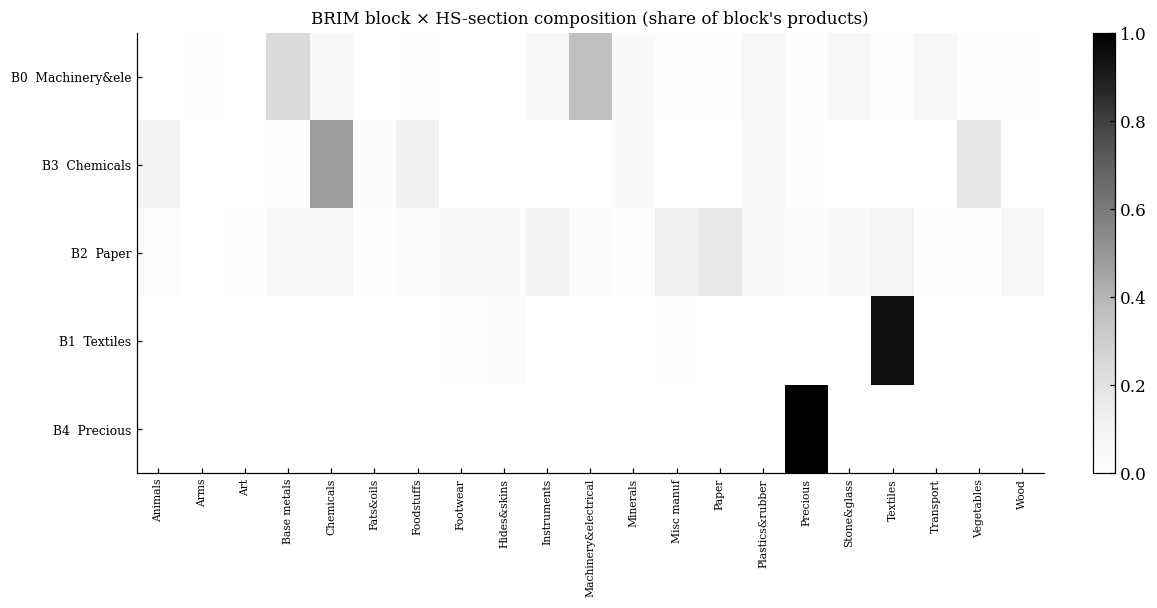

In [9]:
def block_summary(pb):
    used = pb >= 0
    df = pd.DataFrame({"sec": SECNAME[used], "block": pb[used]})
    out = []
    for blk, g in df.groupby("block"):
        vc = g.sec.value_counts()
        out.append({"block": int(blk), "n_products": len(g), "n_sections": g.sec.nunique(),
                    "dominant_section": vc.index[0], "purity": vc.iloc[0]/len(g)})
    res = pd.DataFrame(out)
    fa = np.asarray(M.sum(1)).ravel() > 0
    res["n_firms"] = res["block"].map(pd.Series(FB[fa]).value_counts()).fillna(0).astype(int)
    return res.sort_values("n_products", ascending=False).reset_index(drop=True)

bs = block_summary(PB)
show(bs[["block","n_firms","n_products","n_sections","dominant_section","purity"]],
     "BRIM blocks (late-8, HS6)")

used = PB >= 0
sec_lab = pd.factorize(SECNAME[used])[0]
ari_hs = adjusted_rand_score(PB[used], sec_lab); nmi_hs = normalized_mutual_info_score(PB[used], sec_lab)
print(f"BRIM product-partition vs HS-section partition: ARI = {ari_hs:.3f}, NMI = {nmi_hs:.3f}")
print(f"-> blocks span on average {bs.n_sections.mean():.1f} HS sections; "
      f"the data-driven partition is NOT a relabelling of HS sectors (cf. their Table 2).")

# block x section composition (grayscale, paper style)
top = bs.head(10).block.tolist()
secs_u = sorted(set(SECNAME[used]))
mat = np.zeros((len(top), len(secs_u)))
for i, b in enumerate(top):
    s = SECNAME[used][PB[used] == b]
    for j, sc in enumerate(secs_u):
        mat[i, j] = (s == sc).mean()
fig, ax = plt.subplots(figsize=(11.5, 5.2))
im = ax.imshow(mat, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(len(secs_u))); ax.set_xticklabels(secs_u, rotation=90, fontsize=7)
ax.set_yticks(range(len(top))); _dom = dict(zip(bs.block, bs.dominant_section))
ax.set_yticklabels([f"B{b}  {str(_dom.get(b, ''))[:13]}" for b in top], fontsize=8)
ax.set_title("BRIM block × HS-section composition (share of block's products)", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.025); save_fig(fig, "ds_fig2_block_sections"); plt.show()

## 6c. What our blocks actually contain — and how they compare to De Stefano's
De Stefano describe their **seven** Italian blocks (their §3, quoted):
> *"…we find seven distinct blocks. The largest block mainly includes **machinery and metal products** (~30% of
> firms). Among the remaining six… one in **electrical machinery** (TVs, hard disks), one in **paper and
> plastic**, one in **chemicals and minerals**, one in **textile products**, one in **food and animals**. The
> remaining block is less interpretable (**wood, glass, jewelry**)."*

Below we print, for **each of our blocks**, its size, dominant HS **chapters** (2-digit, named), and its most
**ubiquitous individual products** (named) — so the block content is concrete, not just a sector label. Product
names come from the WCO HS-2007 metadata table shipped with the EFC summer-school materials.

In [10]:
# readable HS6 -> product name and HS2 -> chapter name (WCO HS-2007 metadata)
META = (RAW_DTA.parents[2] / "scripts" / "EFC - complexity summer school" /
        "Coding labs" / "data" / "export" / "HS_2007" / "products_metadata.tsv")
if META.exists():
    _m = pd.read_csv(META, sep="\t", dtype=str)
    HS6_NAME = dict(zip(_m.Code.astype(int), _m.Description))
    HS2_NAME = dict(zip(_m.Code.astype(int), _m.Description_2dig))
else:
    HS6_NAME, HS2_NAME = {}, {}
def chap_name(hs6):
    return HS2_NAME.get(int(hs6) // 10000, section_name(hs6))
def prod_name(hs6):
    return str(HS6_NAME.get(int(hs6), hs6))

ubi = np.asarray(M.sum(0)).ravel(); fa = np.asarray(M.sum(1)).ravel() > 0
print(f"=== OUR {n_blocks(FB, PB)} BRIM BLOCKS (late-8, HS6, {fa.sum():,} active firms) ===")
for blk in pd.Series(PB[PB >= 0]).value_counts().index:
    prods = PROD[PB == blk]; nf = int((FB[fa] == blk).sum())
    chs = pd.Series([chap_name(h) for h in prods]).value_counts()
    topp = sorted(prods, key=lambda h: -ubi[PCOL[h]])[:6]
    print(f"\\nBLOCK {blk}: {nf:,} firms ({nf/fa.sum():.0%}), {len(prods)} HS6 products")
    print("  dominant HS chapters:")
    for nm, cnt in chs.head(4).items():
        print(f"    {cnt:4d} ({cnt/len(prods):4.0%})  {str(nm)[:64]}")
    print("  most ubiquitous products:")
    for h in topp:
        print(f"    - {prod_name(h)[:74]}")

=== OUR 5 BRIM BLOCKS (late-8, HS6, 71,017 active firms) ===
\nBLOCK 0: 36,321 firms (51%), 1995 HS6 products
  dominant HS chapters:
     719 ( 36%)  Machinery&electrical
     484 ( 24%)  Base metals
     143 (  7%)  Instruments
     124 (  6%)  Plastics&rubber
  most ubiquitous products:
    - Plastics; other articles n.e.c. in chapter 39
    - Iron or steel; articles n.e.c. in heading no. 7326
    - Aluminium; n.e.c. in heading no. 7616
    - Rubber; vulcanised (other than hard rubber), articles n.e.c. in heading no
    - Electrical apparatus; parts suitable for use solely or principally with th
    - Taps, cocks, valves and similar appliances; parts thereof
\nBLOCK 3: 7,691 firms (11%), 1173 HS6 products
  dominant HS chapters:
     558 ( 48%)  Chemicals
     207 ( 18%)  Vegetables
     139 ( 12%)  Foodstuffs
     126 ( 11%)  Animals
  most ubiquitous products:
    - Chemical products, preparations and residual products of the chemical or a
    - 293390
    - Heterocyclic compounds

### Block-by-block comparison with De Stefano (validation)

| De Stefano block (Italy, 7) | Our block (China, 5) | Match |
|---|---|---|
| Machinery & metal (largest, ~30% firms) | **Block 0** (~51% firms): machinery, metals, **+ electrical** | ✓ but larger & absorbs electrical |
| Electrical machinery (TVs, hard disks) | folded into **Block 0** | ✗ does not separate in China |
| Chemicals & minerals | **Block 3** (chemicals 48% **+ agri-food ~41%**) | ✓ chemicals match; food bundled in |
| Paper & plastic | **Block 2** (paper, packaging, cases, light mfg) | ✓ partial (ours is packaging-heavy) |
| Textile products | **Block 1** (cotton, apparel, man-made fibres) | ✓ strong, pure match |
| Food & animals | **bundled into Block 3** (with chemicals) | ~ no *standalone* food block |
| Wood / glass / jewelry (least interpretable) | **Block 4** (diamonds/precious, 40 firms) | ~ partial |

**What this validates.** The three economically robust pillars — **textiles, chemicals, machinery/metals** —
emerge in *both* the Italian and Chinese samples with coherent composition and near-identical bipartite
modularity (\(Q_B \approx 0.50\)). The block structure is therefore **not a country artefact**: it reflects
real production capabilities. **The differences make economic sense, not errors:**
- Our machinery block is ~51% (vs ~30%) and **absorbs electrical machinery**: in China machinery–metals–
  electronics form one large, weakly-differentiated export mass ("factory of the world" assembly), and the
  every-year balanced filter further selects big generalist traders.
- **No *standalone* food block**: agri-food does not nucleate its own cluster as in Italy — instead it is
  **bundled with chemicals** in Block 3 (chemicals 48%, vegetables/foodstuffs/animals ~41%), a chemistry-and-
  processing capability bundle.
- **5 vs 7 blocks** is a *merging* difference (electrical → machinery; food → chemicals), not a methodological one.

## 7. Step 3 — In-block and out-of-block diversification
> *De Stefano's headline construct.* With \(\delta_{fp}=\mathbb 1\{\text{block}(f)=\text{block}(p)\}\) on the BRIM
> partition,
$$d^{in}_f=\sum_p M_{fp}\,\delta_{fp},\qquad d^{out}_f=\sum_p M_{fp}(1-\delta_{fp}),\qquad
d_f=d^{in}_f+d^{out}_f,\qquad \text{Share}^{in}_f=\frac{d^{in}_f}{d_f}.$$
\(d^{in}\) = exploitation (deepening one's own capability block), \(d^{out}\) = exploration (branching out).
Descriptive read-out, point by point, exactly on their construct.

Diversification indicators (N = 71,017 active firms)


,N,mean,sd,min,p10,p25,median,p75,p90,max
d_in,71017.0,13.011,20.830,1.000,2.000,4.0,7.0,14.0,29.0,629.0
d_out,71017.0,2.531,11.383,0.000,0.000,0.0,0.0,2.0,5.0,539.0
d,71017.0,15.542,28.525,1.000,2.000,4.0,8.0,17.0,33.0,1005.0
share_in,71017.0,0.888,0.162,0.222,0.625,0.8,1.0,1.0,1.0,1.0


pure in-block (share=1): 54.5% | pure out-of-block (share=0): 0.0% | mixed: 45.5%


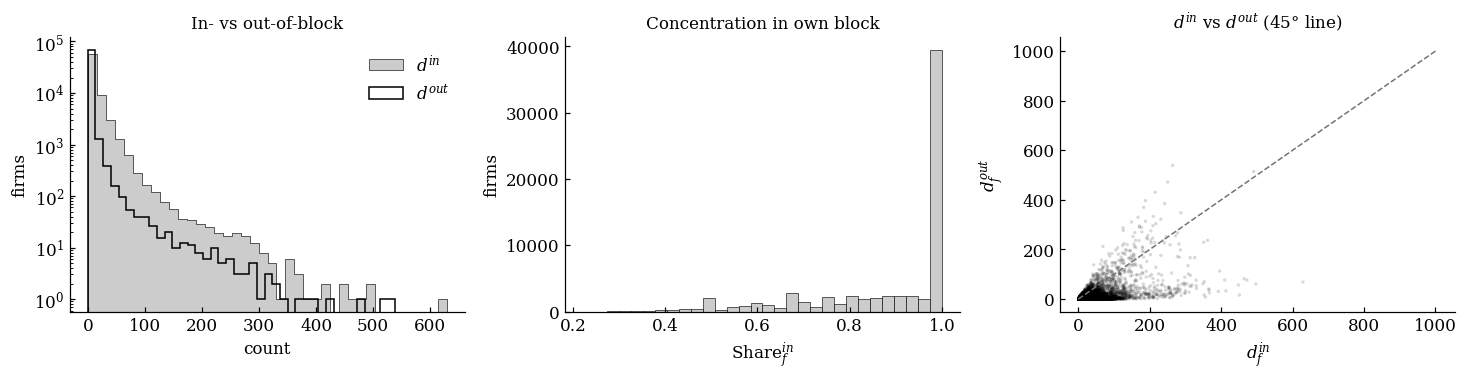

In [11]:
def diversification(Mat, fb, pb):
    Mat = sp.csr_matrix((Mat > 0).astype(np.int8)); coo = Mat.tocoo(); F = Mat.shape[0]
    same = fb[coo.row] == pb[coo.col]
    d_in = np.bincount(coo.row[same], minlength=F)
    d = np.asarray(Mat.sum(1)).ravel().astype(int); d_out = d - d_in
    return d_in, d_out, d

d_in, d_out, d = diversification(M, FB, PB)
act = d > 0
DIV = pd.DataFrame({"d_in": d_in[act], "d_out": d_out[act], "d": d[act]})
DIV["share_in"] = DIV.d_in / DIV.d
assert (DIV.d_in + DIV.d_out == DIV.d).all()
show(summary_stats(DIV, ["d_in", "d_out", "d", "share_in"]),
     f"Diversification indicators (N = {act.sum():,} active firms)")
print(f"pure in-block (share=1): {(DIV.share_in==1).mean():.1%} | "
      f"pure out-of-block (share=0): {(DIV.share_in==0).mean():.1%} | "
      f"mixed: {((DIV.share_in>0)&(DIV.share_in<1)).mean():.1%}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].hist(DIV.d_in, bins=40, color=LGRAY, edgecolor=BLACK, lw=0.4, label="$d^{in}$", histtype="stepfilled")
ax[0].hist(DIV.d_out, bins=40, histtype="step", color=BLACK, lw=1.0, label="$d^{out}$")
ax[0].set_yscale("log"); ax[0].set_xlabel("count"); ax[0].set_ylabel("firms"); ax[0].legend()
ax[0].set_title("In- vs out-of-block", fontsize=11)
ax[1].hist(DIV.share_in, bins=30, color=LGRAY, edgecolor=BLACK, lw=0.4)
ax[1].set_xlabel("Share$^{in}_f$"); ax[1].set_ylabel("firms"); ax[1].set_title("Concentration in own block", fontsize=11)
m = DIV.d.max()
ax[2].scatter(DIV.d_in, DIV.d_out, s=5, color=BLACK, alpha=0.15, edgecolor="none")
ax[2].plot([0, m], [0, m], color=GRAY, lw=1, ls="--"); ax[2].set_xlabel("$d^{in}_f$"); ax[2].set_ylabel("$d^{out}_f$")
ax[2].set_title("$d^{in}$ vs $d^{out}$ (45° line)", fontsize=11)
plt.tight_layout(); save_fig(fig, "ds_fig3_diversification"); plt.show()

## 8. Step 4 — Coherence (Sapling Similarity)
> *De Stefano measure how related a firm's exported products are, using the Sapling-Similarity product
> kernel \(B\) (Albora et al. 2023), weighted by export value \(E_{fp}\):*
$$C_f=\frac{\sum_{p,p'}E_{fp}\,E_{fp'}\,B_{pp'}}{\big(\sum_p E_{fp}\big)^2}.$$
\(B_{pp'}\in[-1,1]\) is high when two products are made together more than chance. High \(C_f\) = a focused,
related basket; low = a scattered one.

Sapling B (1500, 1500) | coherence for 68,434 firms | mean 0.626 | range [0.02, 1.00]


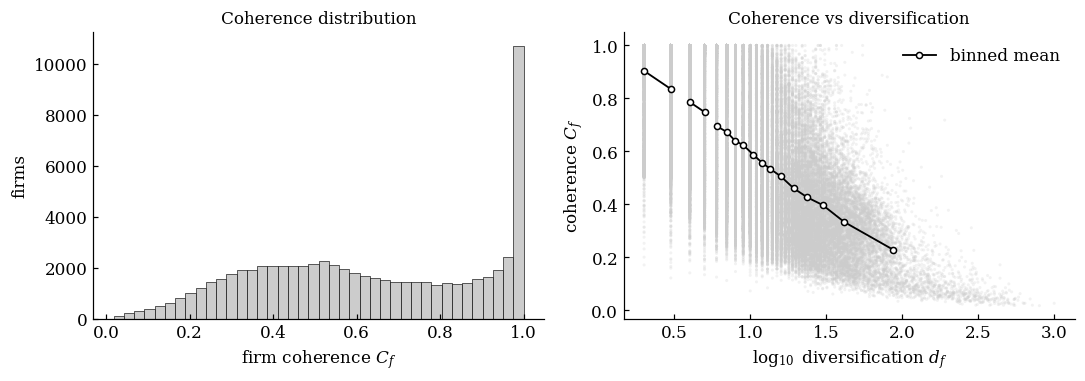

In [12]:
def sapling_similarity(Mbin):
    Mbin = (Mbin > 0).astype(float); N = Mbin.shape[0]
    k = np.asarray(Mbin.sum(0)).ravel(); CO = (Mbin.T @ Mbin)
    if sp.issparse(CO): CO = CO.toarray()
    CO = CO.astype(float); ki = k[:, None]; kj = k[None, :]
    with np.errstate(divide="ignore", invalid="ignore"):
        p_bean = ki/N; p_r = CO/kj; p_l = (ki-CO)/(N-kj)
        GI = lambda p: 2.0*p*(1.0-p)
        dGI = (GI(p_bean) - (kj/N)*GI(p_r) - ((N-kj)/N)*GI(p_l)) / GI(p_bean)
    dGI = np.nan_to_num(dGI, nan=0.0, posinf=0.0, neginf=0.0)
    B = np.sign(p_r - p_bean) * np.clip(dGI, 0.0, 1.0); np.fill_diagonal(B, 1.0)
    return B

def firm_coherence(firms, B, used_cols):
    pos = {int(c): i for i, c in enumerate(used_cols)}
    sub = panel_k[panel_k.firm.isin(set(firms)) & panel_k.col.isin(set(used_cols))]
    sub = sub.groupby(["firm", "col"], sort=False)["value"].sum().reset_index()
    out = {}
    for firm, g in sub.groupby("firm"):
        idx = np.array([pos[c] for c in g.col]); val = g.value.to_numpy(np.float64); s = val.sum()
        if s > 0:
            out[firm] = float(val @ B[np.ix_(idx, idx)] @ val) / (s*s)
    return pd.Series(out, name="coherence")

used_cols = np.argsort(np.asarray(M.sum(0)).ravel())[::-1]
used_cols = used_cols[np.asarray(M.sum(0)).ravel()[used_cols] > 0][:COH_MAX_PRODUCTS]
B = sapling_similarity(M[:, used_cols])
Coh = firm_coherence(KEEP, B, used_cols)
print(f"Sapling B {B.shape} | coherence for {len(Coh):,} firms | mean {Coh.mean():.3f} | "
      f"range [{Coh.min():.2f}, {Coh.max():.2f}]")
degC = np.asarray(M.sum(1)).ravel()[Coh.index.to_numpy()]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(Coh.values, bins=40, color=LGRAY, edgecolor=BLACK, lw=0.4)
ax[0].set_xlabel("firm coherence $C_f$"); ax[0].set_ylabel("firms"); ax[0].set_title("Coherence distribution", fontsize=11)
mask = degC >= 2; mx, my = binned_mean(np.log10(degC[mask]), Coh.values[mask], 20)
ax[1].scatter(np.log10(degC[mask]), Coh.values[mask], s=4, color=LGRAY, alpha=0.25, edgecolor="none")
ax[1].plot(mx, my, marker="o", ms=4, color=BLACK, lw=1.2, mfc="white", label="binned mean")
ax[1].set_xlabel("$\\log_{10}$ diversification $d_f$"); ax[1].set_ylabel("coherence $C_f$")
ax[1].set_title("Coherence vs diversification", fontsize=11); ax[1].legend()
plt.tight_layout(); save_fig(fig, "ds_fig4_coherence"); plt.show()

## 9. Fitness–Complexity (their Appendix C check)
> *De Stefano also compute the Tacchella et al. (2012) economic-complexity metrics and report (Appendix C)
> that product **complexity is not associated with firm growth** — firm performance is largely independent of
> their products' complexity.* The non-linear map, iterated to a fixed point and normalised to mean 1:
$$F_f^{(n)}=\sum_p M_{fp}\,Q_p^{(n-1)},\qquad Q_p^{(n)}=\frac{1}{\sum_f M_{fp}\,/\,F_f^{(n-1)}}.$$
We reproduce the indicator; we **cannot** test their growth association (no firm outcomes — see §10).

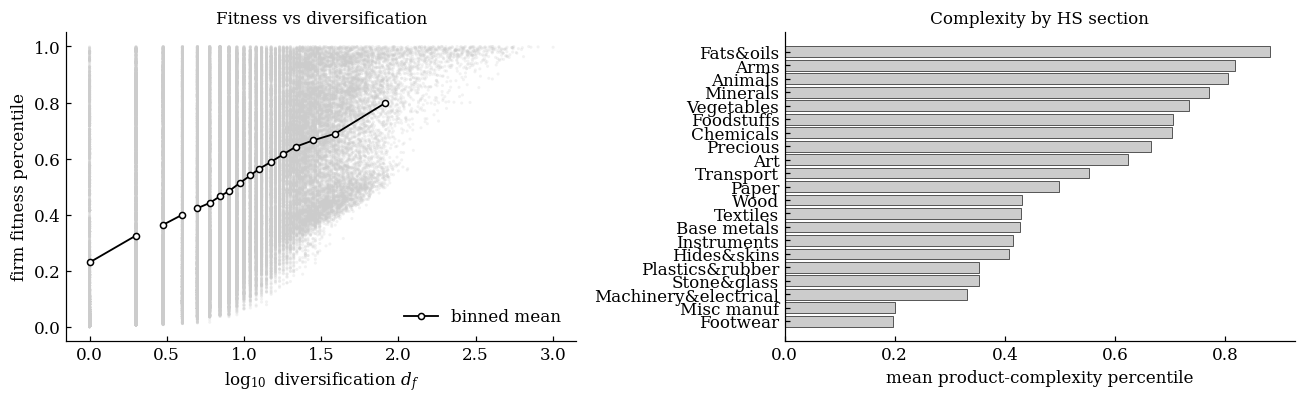

Indicator reproduced. Growth association (their App. C) not testable here -- no firm outcomes.


In [13]:
def fitness_complexity(Mc, n_iter=20):
    Mb = (Mc > 0).astype(float); Fv = np.ones(Mb.shape[0]); Qv = np.ones(Mb.shape[1])
    for _ in range(n_iter):
        Fn = Mb @ Qv; Qn = 1.0/(Mb.T @ (1.0/np.where(Fv > 0, Fv, 1e-12)))
        Fv, Qv = Fn/Fn.mean(), Qn/Qn.mean()
    return Fv, Qv

af = np.asarray(M.sum(1)).ravel() > 0
Mk = M[af]; cm = np.asarray(Mk.sum(0)).ravel() > 0; Mk = Mk[:, cm]; hs_kept = PROD[cm]
Fv, Qv = fitness_complexity(Mk)
deg = np.asarray(Mk.sum(1)).ravel()
secq = pd.Series(Qv.argsort().argsort()/(len(Qv)-1),
                 index=[section_name(h) for h in hs_kept]).groupby(level=0).mean().sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
mx, my = binned_mean(np.log10(deg), Fv.argsort().argsort()/(len(Fv)-1), 20)
ax[0].scatter(np.log10(deg), Fv.argsort().argsort()/(len(Fv)-1), s=4, color=LGRAY, alpha=0.25, edgecolor="none")
ax[0].plot(mx, my, marker="o", ms=4, color=BLACK, lw=1.2, mfc="white", label="binned mean")
ax[0].set_xlabel("$\\log_{10}$ diversification $d_f$"); ax[0].set_ylabel("firm fitness percentile")
ax[0].set_title("Fitness vs diversification", fontsize=11); ax[0].legend()
ax[1].barh(secq.index, secq.values, color=LGRAY, edgecolor=BLACK, lw=0.4)
ax[1].set_xlabel("mean product-complexity percentile"); ax[1].set_title("Complexity by HS section", fontsize=11)
plt.tight_layout(); save_fig(fig, "ds_fig5_fitness"); plt.show()
print("Indicator reproduced. Growth association (their App. C) not testable here -- no firm outcomes.")

## 9b. Who explores out of block? Destinations and the "multinational" reading

De Stefano stop at the firm--product layer. But our microdata also carry the **export destination**
(`country_code`), so we can ask an economic question their data answer less directly: **are the firms with
high out-of-block diversification $d^{out}$ the same firms that ship to many destinations and move large
flows --- the "multinational-like" global exporters?**

Logic. Out-of-block products are capabilities *outside* a firm's own block. Adding them is the
*exploration* margin (March, 1991), which is costly and resource-intensive. Two non-exclusive mechanisms tie
it to destination reach: (i) **demand exposure** --- serving many heterogeneous markets surfaces product
opportunities beyond the core block; (ii) **slack/scale** --- only large, multi-market firms have the
organisational resources to explore. Either way we expect $d^{out}$ to rise with the number of destinations
and with export value.

The honest confound is **size**: big firms have more products *and* more destinations, so a raw positive link
could be mechanical. We therefore also report the association **conditional on total diversification $d$**
(partial Spearman + an OLS with $\log d$ as control): does market reach predict out-of-block exploration
*beyond* simply being a big firm?

destinations read in 12s | median 17 | max 212
active firms with destinations: 71,017
Spearman correlations (firm level)


,d_out,d_in,d,share_out,n_dest,export
d_out,1.000,0.356,0.510,0.947,0.181,0.031
d_in,0.356,1.000,0.977,0.163,0.203,0.174
d,0.510,0.977,1.000,0.338,0.218,0.165
share_out,0.947,0.163,0.338,1.000,0.150,-0.006
n_dest,0.181,0.203,0.218,0.150,1.000,0.432
export,0.031,0.174,0.165,-0.006,0.432,1.000


corr(d_out, n_dest) = 0.181   corr(d_out, export) = 0.031
Mean d^out      rows: flow quintile (F1 low -> F5 high), cols: destination quintile


dest_q,D1,D2,D3,D4,D5
flow_q,,,,,
F1,1.05,1.34,1.66,2.00,3.72
F2,1.24,1.55,1.87,2.40,4.85
F3,1.36,1.40,1.74,2.34,4.90
F4,1.45,1.51,1.76,2.24,4.84
F5,1.75,2.12,1.52,2.28,7.32


Mean out-of-block share %   flow x destinations


dest_q,D1,D2,D3,D4,D5
flow_q,,,,,
F1,10.0,11.5,13.1,14.0,14.8
F2,8.7,10.5,12.1,13.9,16.3
F3,7.7,8.8,10.5,13.0,15.2
F4,7.6,8.1,9.6,11.5,14.6
F5,7.4,7.3,8.5,9.6,13.7



DiD interaction   d^out (count) = +2.90 products   |   share = +1.45 pp   (share ~ 0  =>  no genuine, size-free interaction)


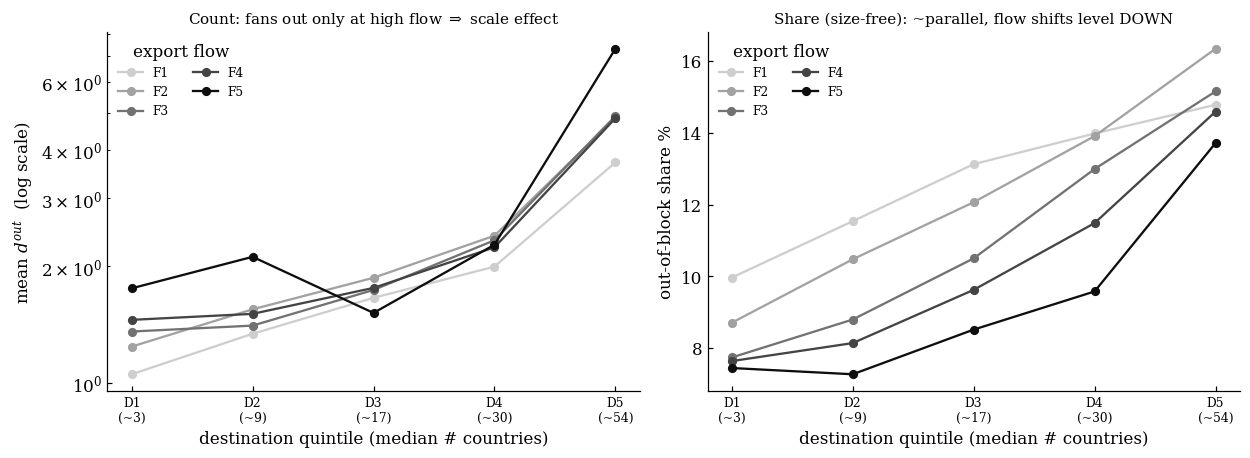

In [14]:
# ---- destinations per firm (second pass over the raw .dta, firm codes reused) ----
import scipy.stats as ss
keep_set = set(int(x) for x in KEEP.tolist())
t0 = time.time(); pair_parts = []
reader2 = pd.read_stata(RAW_DTA, columns=[COL_FIRM, "country_code", COL_YEAR],
                        chunksize=CHUNKSIZE, convert_categoricals=False)
for chunk in reader2:
    chunk = chunk[pd.to_numeric(chunk[COL_YEAR]).isin(yrs)]
    if not len(chunk):
        continue
    codev = chunk[COL_FIRM].astype(str).map(firm_codes); ok = codev.notna()
    sub = pd.DataFrame({"firm": codev[ok].to_numpy(np.int64),
                        "dest": pd.to_numeric(chunk.loc[ok, "country_code"]).to_numpy(np.int32)})
    sub = sub[sub.firm.isin(keep_set)].drop_duplicates()
    if len(sub):
        pair_parts.append(sub)
pairs = pd.concat(pair_parts, ignore_index=True).drop_duplicates()
ndest = pairs.groupby("firm").size().rename("n_dest")
print(f"destinations read in {time.time()-t0:.0f}s | median {ndest.median():.0f} | max {ndest.max()}")

# ---- firm-level frame aligned to the active firms in DIV ----
act_firms = np.where(act)[0]; tot_val = panel_k.groupby("firm")["value"].sum()
FL = DIV.copy()
FL["firm"]      = act_firms
FL["n_dest"]    = FL.firm.map(ndest).fillna(0).astype(int)
FL["export"]    = FL.firm.map(tot_val).fillna(0.0)
FL["share_out"] = 1.0 - FL.share_in
FL = FL[FL.n_dest > 0].copy()
print(f"active firms with destinations: {len(FL):,}")

# ---- descriptive associations: it is destination COUNT, not export VALUE, that tracks d_out ----
rho = FL[["d_out", "d_in", "d", "share_out", "n_dest", "export"]].corr(method="spearman")
show(rho, "Spearman correlations (firm level)")
print(f"corr(d_out, n_dest) = {ss.spearmanr(FL.d_out, FL.n_dest).statistic:.3f}   "
      f"corr(d_out, export) = {ss.spearmanr(FL.d_out, FL.export).statistic:.3f}")

# ---- 5x5 quintiles of export FLOW and destination REACH ----
FL["flow_q"] = pd.qcut(FL.export, 5, labels=[f"F{i}" for i in range(1, 6)])
FL["dest_q"] = pd.qcut(FL.n_dest.rank(method="first"), 5, labels=[f"D{i}" for i in range(1, 6)])
gd = FL.pivot_table("d_out",     "flow_q", "dest_q", aggfunc="mean", observed=True)
gs = FL.pivot_table("share_out", "flow_q", "dest_q", aggfunc="mean", observed=True) * 100
dmed = FL.groupby("dest_q", observed=True)["n_dest"].median().round().astype(int)   # median countries/quintile
show(gd.round(2), "Mean d^out      rows: flow quintile (F1 low -> F5 high), cols: destination quintile")
show(gs.round(1), "Mean out-of-block share %   flow x destinations")

# ---- interaction = does the destination gradient differ by flow? (difference-in-differences) ----
def did(G):
    return (G.iloc[-1, -1] - G.iloc[-1, 0]) - (G.iloc[0, -1] - G.iloc[0, 0])
print(f"\nDiD interaction   d^out (count) = {did(gd):+.2f} products   |   "
      f"share = {did(gs):+.2f} pp   (share ~ 0  =>  no genuine, size-free interaction)")

# ---- ONE figure: interaction plots, 5 flow-quintile lines (light grey = low flow, black = high flow) ----
shades = [plt.cm.Greys(x) for x in np.linspace(0.30, 0.95, 5)]
xt = list(range(gd.shape[1])); xl = [f"D{i}\n(~{dmed.iloc[i-1]})" for i in range(1, 6)]
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
for r, (idx, row) in enumerate(gd.iterrows()):
    ax[0].plot(xt, row.values, marker="o", ms=5, lw=1.5, color=shades[r], label=idx)
for r, (idx, row) in enumerate(gs.iterrows()):
    ax[1].plot(xt, row.values, marker="o", ms=5, lw=1.5, color=shades[r], label=idx)
ax[0].set_yscale("log")
ax[0].set_ylabel("mean $d^{out}$  (log scale)")
ax[0].set_title("Count: fans out only at high flow $\\Rightarrow$ scale effect", fontsize=10)
ax[1].set_ylabel("out-of-block share %")
ax[1].set_title("Share (size-free): ~parallel, flow shifts level DOWN", fontsize=10)
for a in ax:
    a.set_xticks(xt); a.set_xticklabels(xl, fontsize=8)
    a.set_xlabel("destination quintile (median # countries)")
    a.legend(title="export flow", fontsize=8, ncol=2)
plt.tight_layout(); save_fig(fig, "ds_fig6_dest_interaction"); plt.show()

Flow profile with destination reach held fixed (equal-weight avg over dest quintiles)


,d_in,d_out,out-of-block share %
flow_q,,,
F1,9.21,1.95,12.68
F2,11.27,2.38,12.30
F3,12.81,2.35,11.04
F4,14.92,2.36,10.29
F5,17.14,3.00,9.30


F1 -> F5 (reach-fixed):  d_in x1.86   d_out x1.53   share 12.7% -> 9.3%   => d_in grows more in proportion, so the share falls


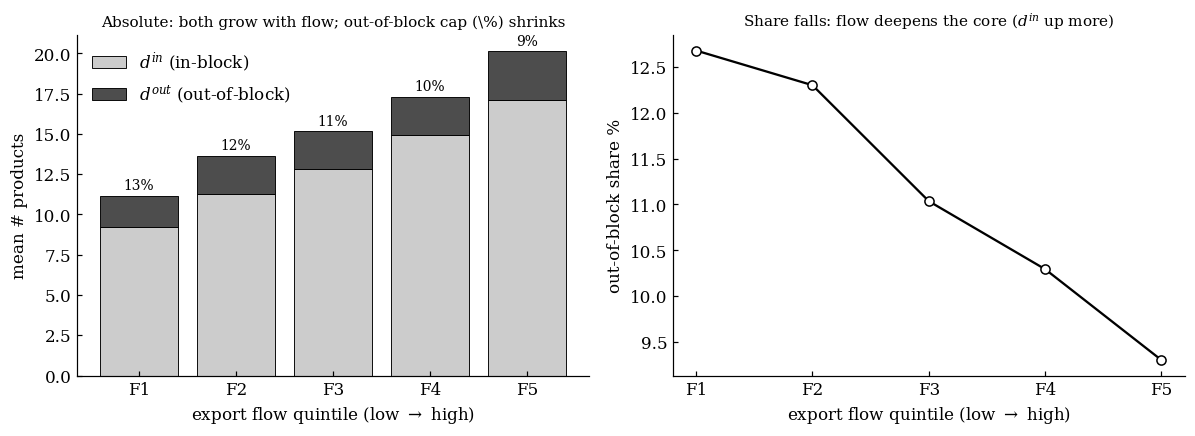

In [15]:
# ---- mechanism: more flow => BOTH d_in and d_out rise, but d_in rises MORE in proportion => share falls ----
# hold destination reach fixed: equal-weight average over destination quintiles (removes the flow-reach confound)
gi  = FL.pivot_table("d_in",     "flow_q", "dest_q", aggfunc="mean", observed=True)
go  = FL.pivot_table("d_out",    "flow_q", "dest_q", aggfunc="mean", observed=True)
gsh = FL.pivot_table("share_out","flow_q", "dest_q", aggfunc="mean", observed=True) * 100
din_f, dout_f, sh_f = gi.mean(axis=1), go.mean(axis=1), gsh.mean(axis=1)
prof = pd.DataFrame({"d_in": din_f, "d_out": dout_f, "out-of-block share %": sh_f})
show(prof.round(2), "Flow profile with destination reach held fixed (equal-weight avg over dest quintiles)")
print(f"F1 -> F5 (reach-fixed):  d_in x{din_f.iloc[-1]/din_f.iloc[0]:.2f}   "
      f"d_out x{dout_f.iloc[-1]/dout_f.iloc[0]:.2f}   "
      f"share {sh_f.iloc[0]:.1f}% -> {sh_f.iloc[-1]:.1f}%   "
      f"=> d_in grows {'more' if (din_f.iloc[-1]/din_f.iloc[0])>(dout_f.iloc[-1]/dout_f.iloc[0]) else 'less'} "
      f"in proportion, so the share {'falls' if sh_f.iloc[-1]<sh_f.iloc[0] else 'rises'}")

x = np.arange(len(din_f)); lab = [f"F{i}" for i in range(1, 6)]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].bar(x, din_f.values, color="0.80", edgecolor="black", lw=.6, label="$d^{in}$ (in-block)")
ax[0].bar(x, dout_f.values, bottom=din_f.values, color="0.30", edgecolor="black", lw=.6, label="$d^{out}$ (out-of-block)")
for i in x:
    ax[0].text(i, din_f.iloc[i] + dout_f.iloc[i] + 0.4, f"{sh_f.iloc[i]:.0f}%", ha="center", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(lab); ax[0].set_xlabel("export flow quintile (low $\\to$ high)")
ax[0].set_ylabel("mean # products"); ax[0].legend(loc="upper left")
ax[0].set_title("Absolute: both grow with flow; out-of-block cap (\\%) shrinks", fontsize=10)
ax[1].plot(x, sh_f.values, marker="o", ms=6, color="black", lw=1.5, mfc="white")
ax[1].set_xticks(x); ax[1].set_xticklabels(lab); ax[1].set_xlabel("export flow quintile (low $\\to$ high)")
ax[1].set_ylabel("out-of-block share %")
ax[1].set_title("Share falls: flow deepens the core ($d^{in}$ up more)", fontsize=10)
plt.tight_layout(); save_fig(fig, "ds_fig7_flow_mechanism"); plt.show()

### Result (descriptive) — out-of-block exploration tracks **destination reach**, not export volume

We test the narrative "the multinationals are the firms that explore out of block ($d^{out}$)" with a single
descriptive cut: 5×5 quintiles of **export flow** (value) and **destination reach** (countries), mean outcome
per cell. Figure `ds_fig6_dest_interaction` shows it; correlations confirm the headline:
$\text{corr}(d^{out}, n_\text{dest}) = 0.18$ vs $\text{corr}(d^{out}, \text{export}) = 0.03$.

**Read the figure (one figure, two panels):**

- **Right panel — out-of-block share %, the size-free read.** Every line rises strongly from few to many
  destinations (D1→D5): more markets → a larger share of the portfolio sits outside the core block. And the
  lines are stacked by flow with **low flow on top, high flow at the bottom** — at any given reach, the
  higher-volume firms are *more* core-concentrated, not less. So **destinations push the portfolio outward;
  volume pulls it inward.**

- **Left panel — count $d^{out}$ (log scale).** Lines overlap across D1–D4 and **fan out only in the last
  destination quintile**, where the top-flow line jumps. That corner (high flow × many destinations) holds the
  largest, broadest firms; the jump is a **scale effect**, not a new mechanism.

**Interaction (difference-in-differences across the corners).** $+2.90$ products on the *count* but only
$+1.45$ pp on the size-free *share* — the count "synergy" is mostly the big-and-broad firms simply being
large. On the proportion, the flow lines stay roughly parallel (slightly converging at high reach), so there
is **no strong, size-free complementarity**: destinations and volume act as largely separate, opposite forces.

**Why flow lowers the share (mechanism, Fig. `ds_fig7_flow_mechanism`).** Holding destination reach fixed, moving from the lowest to the highest export-flow quintile raises *both* margins in absolute terms ($d^{in}$ x1.86, $d^{out}$ x1.53) — but $d^{in}$ grows **more in proportion**, so the out-of-block *share* falls from 12.7% to 9.3%. Scaling in export value comes from **deepening in the core** (specialisation), not from scattering into unrelated products: RCA is scale-invariant, so high value reflects a more core-concentrated product *mix*, not merely a bigger firm. The stacked bars show the total basket growing while the out-of-block cap (13% -> 9%) thins.

**Verdict on the narrative.**

- **"Multinational" = wide destination reach** → the story **holds**, cleanly and monotonically, on both
  $d^{out}$ and the size-free out-of-block share. These are the explorers.
- **"Multinational" = large export volume** → it **fails**: volume alone does not create exploration, and
  proportionally the high-volume firms are *deeper core specialists*.

So $d^{out}$ is the signature of the **wide-reach exporter**, not the big-revenue one — define the
"multinational" type on **geographic breadth**, and the descriptive evidence supports the claim. No regression,
no causal reading: just cell means, with the share panel doing the size-free work.

## 9c. Where does $d^{out}$ live? In-/out-of-block diversification across the capability blocks

Having shown *which firms* explore out of block (the wide-reach exporters), we now ask *which capability
blocks* they sit in: how $d^{in}$ and $d^{out}$ distribute across the five BRIM blocks, and whether the
"more destinations $\Rightarrow$ more out-of-block" pattern survives **within** each block.

One structural caveat to read the table with: out-of-block share depends mechanically on **block size**. A
firm in the large generalist block has a big in-block menu, so few of its products fall outside; a firm in a
small, pure block (textiles, diamonds) has few in-block options, so a larger share is out-of-block by
construction. We therefore report the number of products per block alongside the means.

d_in / d_out by BRIM block (sorted by out-of-block share)


,n_firms,mean_d_in,mean_d_out,share_out_pct,med_dest,med_export_USD,block_products
B2 Paper,16095,8.56,4.46,21.49,22.0,11971166.0,715
B3 Chemicals,7691,9.01,1.50,8.98,14.0,19890494.0,1173
B1 Textiles,10870,24.55,3.10,8.60,15.0,21025011.0,698
B0 Machinery&el,36321,12.39,1.73,7.90,17.0,14945828.0,1995
B4 Precious,40,1.55,0.02,0.62,3.0,57834591.5,5


Out-of-block share % by destination tercile, WITHIN each block


dest_t3,few,mid,many
B0 Machinery&el,6.5,7.7,9.5
B1 Textiles,6.5,7.5,11.8
B2 Paper,19.9,20.9,23.6
B3 Chemicals,7.9,9.9,9.1
B4 Precious,0.0,0.0,1.9


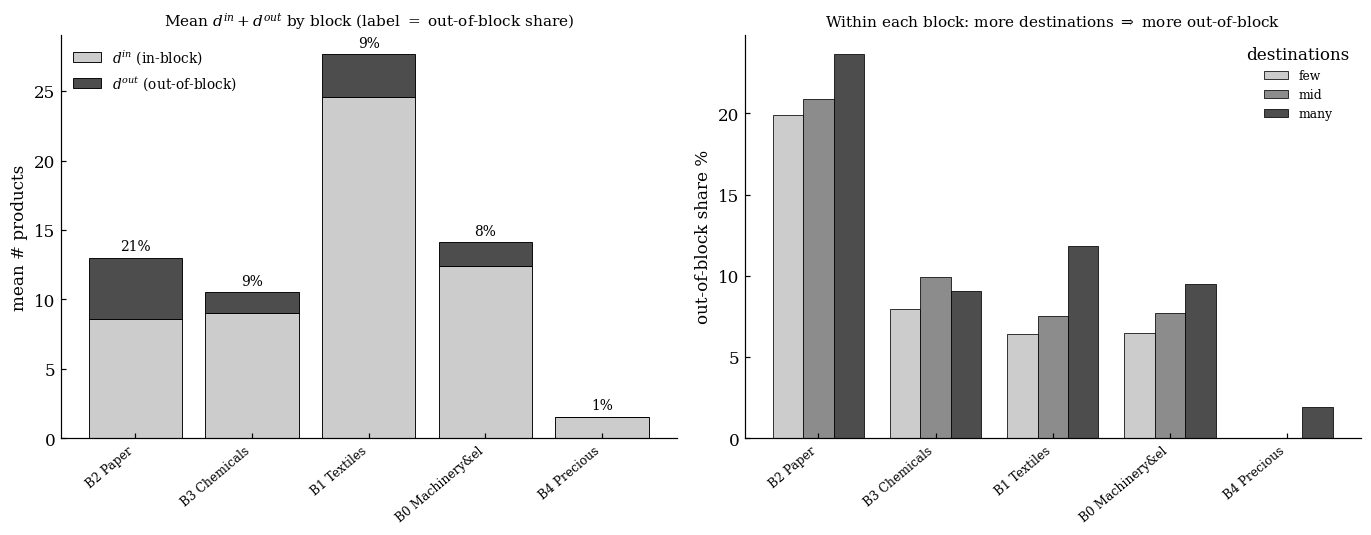

In [16]:
# ---- d_in/d_out across the BRIM blocks ----
FL["block"] = FB[FL.firm.values]
nprod_blk = pd.Series(PB[PB >= 0]).value_counts()

def block_label(b):
    prods = PROD[PB == b]
    if len(prods) == 0:
        return f"B{b}"
    top = pd.Series([chap_name(h) for h in prods]).value_counts().index[0]
    return f"B{b} {str(top)[:12]}"
LBL = {b: block_label(b) for b in sorted(FL.block.unique())}

btab = FL.groupby("block").agg(
    n_firms=("firm", "size"), mean_d_in=("d_in", "mean"), mean_d_out=("d_out", "mean"),
    share_out_pct=("share_out", lambda s: 100 * s.mean()),
    med_dest=("n_dest", "median"), med_export_USD=("export", "median"))
btab["block_products"] = btab.index.map(nprod_blk).astype(int)
btab.index = [LBL[b] for b in btab.index]
btab = btab.sort_values("share_out_pct", ascending=False)
show(btab.round(2), "d_in / d_out by BRIM block (sorted by out-of-block share)")

# ---- does 'more destinations -> higher out-of-block share' hold WITHIN each block? ----
def safe_t3(s):
    try:
        return pd.qcut(s.rank(method="first"), 3, labels=["few", "mid", "many"])
    except Exception:
        return pd.Series(["mid"] * len(s), index=s.index)
FL["dest_t3"] = FL.groupby("block")["n_dest"].transform(safe_t3)
wb = FL.pivot_table("share_out", "block", "dest_t3", aggfunc="mean", observed=True) * 100
wb.index = [LBL[b] for b in wb.index]
show(wb.round(1), "Out-of-block share % by destination tercile, WITHIN each block")

# ---- figure (harmonised with ds_fig6 / ds_fig7 style) ----
order = list(btab.index)                                   # blocks sorted by out-of-block share
fig, ax = plt.subplots(1, 2, figsize=(12.6, 5.0))

# (a) stacked d_in / d_out by block  --  same vocabulary as ds_fig7 (0.80 / 0.30, share % annotated)
x = np.arange(len(order))
din_b = btab["mean_d_in"].values; dout_b = btab["mean_d_out"].values; sh_b = btab["share_out_pct"].values
ax[0].bar(x, din_b, color="0.80", edgecolor="black", lw=.6, label="$d^{in}$ (in-block)")
ax[0].bar(x, dout_b, bottom=din_b, color="0.30", edgecolor="black", lw=.6, label="$d^{out}$ (out-of-block)")
for i in x:
    ax[0].text(i, din_b[i] + dout_b[i] + 0.5, f"{sh_b[i]:.0f}%", ha="center", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(order, rotation=40, ha="right", fontsize=8)
ax[0].set_ylabel("mean # products"); ax[0].legend(loc="upper left", fontsize=9)
ax[0].set_title("Mean $d^{in}+d^{out}$ by block (label $=$ out-of-block share)", fontsize=10)

# (b) within-block destination gradient as grouped bars (consistent bar vocabulary, grey gradient)
wbo = wb.loc[order].reindex(columns=["few", "mid", "many"])
greys = ["0.80", "0.55", "0.30"]; bw = 0.26; xb = np.arange(len(order))
for j, t in enumerate(["few", "mid", "many"]):
    ax[1].bar(xb + (j - 1) * bw, wbo[t].values, width=bw, color=greys[j],
              edgecolor="black", lw=.5, label=t)
ax[1].set_xticks(xb); ax[1].set_xticklabels(order, rotation=40, ha="right", fontsize=8)
ax[1].set_ylabel("out-of-block share %")
ax[1].legend(title="destinations", fontsize=8)
ax[1].set_title("Within each block: more destinations $\\Rightarrow$ more out-of-block", fontsize=10)
plt.tight_layout(); save_fig(fig, "ds_fig8_blocks"); plt.show()

## 10. Summary — our results vs De Stefano

| Quantity | De Stefano (Italy, 1993–2017) | Ours (China, late-8 2008–15, HS6) | Read |
|---|---|---|---|
| Sample rule | exports every year (balanced) | exports every year (balanced) | identical |
| Firms / HS6 | 18,597 / 5,203 | 71,017 / 4,586 | larger N |
| **BRIM blocks** | **7** | **5** | same order; merge differences |
| **Bipartite modularity \(Q_B\)** | **0.501** | **0.505** | **essentially identical** |
| Blocks ≠ HS sectors (their Table 2) | yes | yes (ARI 0.29, NMI 0.43) | **replicated** |
| In-block vs out-of-block split | meaningful | 54.5% pure-in / 45.5% mixed | **construct works** |
| Coherence (Sapling) | computed | mean 0.626 | reproduced |
| Fitness–complexity | computed; complexity ≠ growth (App. C) | reproduced | not testable on growth here |

**What we validate.**
1. **The block structure is real and portable.** \(Q_B \approx 0.50\) in both countries; the three pillars
   (textiles, chemicals, machinery/metals) recur with coherent product content. Not a country artefact.
2. **Blocks carry information beyond HS sectors** (their core Table-2 claim): low ARI/NMI vs an HS-section
   partition, blocks spanning ~13 sections.
3. **The in/out-of-block diversification construct is well-defined and interpretable** on Chinese data.

**Where we differ, and why it is economically sensible** (not a replication failure): China's machinery–
metals–electronics collapse into one large generalist block (~51% of firms), and agri-food does not form a
standalone block but is **bundled with chemicals** (Block 3). This yields 5 rather than 7 blocks — a *merging*
difference, with the same \(Q_B\).

**What we cannot judge:** whether these indicators *predict firm growth/profit* (their headline regressions)
— that needs ORBIS financials we do not have (see §12).

## 11. Robustness — only the checks De Stefano report
De Stefano's robustness exercises and their status on these data:

| Their robustness check | Status here |
|---|---|
| **BRIM blocks vs HS-sector blocks** (data-driven partition matters; Table 2) | **Done** (§6): ARI/NMI low → blocks ≠ HS sectors |
| **HS4 vs HS6 communities** (partition robust to granularity) | Restricted to HS6 by request (see the companion multi-level notebook for HS4 vs HS6) |
| **EXPY weighting** (export-volume vs RCA weights) | N/A — needs EXPY, not computable here (§11) |

The one fully reproducible robustness check is the BRIM-vs-HS-sector comparison from §6, restated here.

In [17]:
print("Robustness (De Stefano Table 2 logic) — BRIM vs HS-sector partition:")
print(f"  ARI(BRIM, HS-section) = {ari_hs:.3f}   NMI(BRIM, HS-section) = {nmi_hs:.3f}")
print(f"  blocks span {bs.n_sections.mean():.1f} HS sections on average "
      f"(min {bs.n_sections.min()}, max {bs.n_sections.max()})")
print("  => the capability blocks are NOT a relabelling of HS sectors: a data-driven partition")
print("     carries structure that naive sector dummies miss (consistent with their Table 2).")

Robustness (De Stefano Table 2 logic) — BRIM vs HS-sector partition:
  ARI(BRIM, HS-section) = 0.289   NMI(BRIM, HS-section) = 0.426
  blocks span 13.0 HS sections on average (min 1, max 21)
  => the capability blocks are NOT a relabelling of HS sectors: a data-driven partition
     carries structure that naive sector dummies miss (consistent with their Table 2).


## 12. What we cannot replicate, and why
Two parts of De Stefano's paper require data outside a single country's firm–product exports:

- **EXPY / PRODY (Hausmann–Hwang–Rodrik 2007; Hausmann–Hidalgo 2009).** \(\mathrm{PRODY}_p=\sum_c
  \frac{\mathrm{RCA}_{cp}}{\sum_{c'}\mathrm{RCA}_{c'p}}\,\mathrm{GDP}_c\) and \(\mathrm{EXPY}_f=\sum_p
  \frac{X_{fp}}{\sum_{p'}X_{fp'}}\mathrm{PRODY}_p\) are built from the **world country–product** trade matrix
  and GDP per capita. Our data are Chinese firms exporting to destinations — there is no cross-country
  exporter variation to estimate \(\mathrm{PRODY}_p\). *Feasible only with BACI world trade + Penn/WB GDP.*
- **Regressions on Growth and Profit per Employee.** De Stefano regress smoothed operating-revenue growth and
  profit/employee on the indicators with HS-sector dummies and robust SE. These outcomes come from **ORBIS
  firm financials**, which we do not have. *Feasible only by merging firm balance-sheet data.*

Everything in §4–§9 (RCA → BRIM → \(d^{in}/d^{out}\) → coherence → fitness) is computed exactly as they
describe.

## 13. References
- Albora, G., Rossi Mori, L., Zaccaria, A. (2023). Sapling Similarity: a performing and interpretable memory-based tool for recommendation. *arXiv:2210.07039.*
- Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School* 33(2): 99–123. doi:10.1111/j.1467-9957.1965.tb00050.x
- Barber, M. J. (2007). Modularity and community detection in bipartite networks. *Physical Review E* 76(6): 066102. doi:10.1103/PhysRevE.76.066102
- Blondel, V. D., Guillaume, J.-L., Lambiotte, R., Lefebvre, E. (2008). Fast unfolding of communities in large networks (**Louvain**). *J. Stat. Mech.* P10008. doi:10.1088/1742-5468/2008/10/P10008
- Danon, L., Díaz-Guilera, A., Duch, J., Arenas, A. (2005). Comparing community structure identification (**NMI**). *J. Stat. Mech.* P09008. doi:10.1088/1742-5468/2005/09/P09008
- De Stefano, V., Mula, M., Mariani, M. S., Zaccaria, A. (2025). From macro to micro: economic complexity indicators for firm growth. *arXiv:2507.21754* (preprint; → *Research Policy*).
- Hausmann, R., Hwang, J., Rodrik, D. (2007). What you export matters (**EXPY/PRODY**). *Journal of Economic Growth* 12(1): 1–25. doi:10.1007/s10887-006-9009-4
- Hausmann, R., Hidalgo, C. A. (2009). The building blocks of economic complexity. *PNAS* 106(26): 10570–10575. doi:10.1073/pnas.0900943106
- Hidalgo, C. A., Klinger, B., Barabási, A.-L., Hausmann, R. (2007). The product space conditions the development of nations. *Science* 317(5837): 482–487. doi:10.1126/science.1144581
- Hubert, L., Arabie, P. (1985). Comparing partitions (**Adjusted Rand Index**). *Journal of Classification* 2: 193–218. doi:10.1007/BF01908075
- March, J. G. (1991). Exploration and exploitation in organizational learning. *Organization Science* 2(1): 71–87. doi:10.1287/orsc.2.1.71
- Newman, M. E. J. (2006). Modularity and community structure in networks. *PNAS* 103(23): 8577–8582. doi:10.1073/pnas.0601602103
- Tacchella, A., Cristelli, M., Caldarelli, G., Gabrielli, A., Pietronero, L. (2012). A new metrics for countries' fitness and products' complexity. *Scientific Reports* 2: 723. doi:10.1038/srep00723
- Traag, V. A., Waltman, L., van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports* 9: 5233. doi:10.1038/s41598-019-41695-z
- World Customs Organization. *Harmonized System (HS) Nomenclature.*